# DyslexAI — Notebook 02: Cleaning & Splits (cropped data)

**Final Year Project — Software Engineering**
**Phase 2B | Handwriting modality | Jira: DYS-16**

> **Revised version.** This replaces the earlier hash-based cleaning notebook, which no longer
> works on manually cropped images. See Stage 1 for why.

---

## What this notebook does

Produces the exact file lists every model trains on. It trains nothing.

## What changed from the previous version

Two things

### 1. Deduplication now runs on provenance, not on content

The previous version found duplicates by hashing each file. Manual ROI cropping changed every
file's bytes, so byte-identical source images are no longer byte-identical after cropping.
Hashing the crops finds **zero** duplicates in a dataset that still contains 214 redundant
copies and 48 contradictory files.

Notebook 01b recovered the structure by joining the crops to the original audit on filename.
This notebook consumes that recovered `duplicate_group` column. It never hashes a cropped file
to decide what to remove.

### 2. Date-based session grouping is no longer the primary split

A capture day is not a participant. One school visit photographs many children, so grouping by
date never gave writer independence — it only separated recording occasions. The decision was
taken to stop presenting it as the main evaluation split.

It remains available as a **diagnostic** in Stage 6.3, clearly labelled, because the gap between
a random split and a session-held-out split is informative even though neither is
writer-independent. That stage can be skipped without affecting anything downstream.

---

## Stage map

| Stage | Name | Output |
|---|---|---|
| 0 | Setup — rebuild session state | |
| 1 | Cleaning policy | A written, defensible rule set |
| 2 | Build **A1_raw** | All 852 cropped files |
| 3 | Build **A2_clean** + removal log | Deduplicated, de-conflicted |
| 4 | Verification assertions | |
| 5 | Split strategy | |
| 6 | Build the splits | Manifests |
| 7 | Leakage audit **by provenance** | Measured, not assumed |
| 8 | Figures | |
| 9 | Report and log | |

---

## The two dataset versions

**A1_raw** — all 852 cropped files, duplicates and contradictions intact. What a researcher
gets by downloading the dataset and training without looking. We measure what it produces; we
do not endorse it.

**A2_clean** — deduplicated and de-conflicted, every removal logged. Our pilot dataset.

---
# STAGE 0 — Setup

Rebuilds what Notebook 01b established. Each notebook runs standalone, because Colab sessions
die and you should never need to run four notebooks in order to resume.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os, sys, json, random, subprocess, time, re
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
from PIL import Image

DRIVE_ROOT   = Path('/content/drive/MyDrive')
PROJECT_DIR  = DRIVE_ROOT / 'DyslexAI'
ARCHIVE_DIR  = PROJECT_DIR / 'archives'
RAW_DIR      = Path('/content/raw')

INTERIM_DIR  = PROJECT_DIR / 'data' / 'interim'
CLEANED_DIR  = PROJECT_DIR / 'data' / 'cleaned'
SPLITS_DIR   = PROJECT_DIR / 'data' / 'splits'
REPORTS_DIR  = PROJECT_DIR / 'reports'
FIGURES_DIR  = PROJECT_DIR / 'results' / 'figures'

for d in [RAW_DIR, CLEANED_DIR, SPLITS_DIR, REPORTS_DIR, FIGURES_DIR]:
    d.mkdir(parents=True, exist_ok=True)

SEED = 42

def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(SEED)

IMG_EXT = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff', '.webp'}
print('Paths ready. Seed =', SEED)

Paths ready. Seed = 42


In [ ]:
# ---- Re-extract the cropped images ----------------------------------------
!apt-get -qq install -y libarchive-tools > /dev/null 2>&1

CROP_DIR = RAW_DIR / 'dataset_a_cropped'

if not any(CROP_DIR.rglob('*.jpeg')):
    CROP_DIR.mkdir(parents=True, exist_ok=True)
    for archive in ['Cropped_No.zip', 'Cropped_Yes.zip']:
        subprocess.run(['bsdtar', '-xf', str(ARCHIVE_DIR / archive),
                        '-C', str(CROP_DIR)], capture_output=True, check=False)
    print('Extracted crops.')
else:
    print('Already extracted this session.')


def find_image_dir(root: Path, class_name: str, min_files: int = 100) -> Path:
    """Locate a class's image folder wherever the zip placed it."""
    candidates = []
    for d in [root] + [p for p in root.rglob('*') if p.is_dir()]:
        n = sum(1 for f in d.iterdir()
                if f.is_file() and f.suffix.lower() in IMG_EXT)
        if n >= min_files and class_name.lower() in d.name.lower():
            candidates.append((n, d))
    if not candidates:
        raise FileNotFoundError(f'No folder for class {class_name!r} under {root}')
    candidates.sort(reverse=True)
    return candidates[0][1]


CROP_DIRS = {cls: find_image_dir(CROP_DIR, cls) for cls in ['No', 'Yes']}
for cls, d in CROP_DIRS.items():
    print(f'  {cls:<4} {d}')

Extracted crops.
  No   /content/raw/dataset_a_cropped/Dataset_Cropped_No/No
  Yes  /content/raw/dataset_a_cropped/Yes


In [ ]:
# ---- Load the cropped metadata from Notebook 01b ---------------------------
CROP_META_PATH = INTERIM_DIR / 'dataset_a_cropped_metadata.csv'
meta = pd.read_csv(CROP_META_PATH)

# abs_path points at a wiped filesystem — rebuild it from the portable columns
meta['abs_path'] = meta.apply(
    lambda r: str(Path(CROP_DIRS[r['class_label']]) / r['original_filename']), axis=1)

missing = [p for p in meta['abs_path'] if not Path(p).exists()]
assert not missing, f'{len(missing)} files missing, e.g. {missing[:3]}'

print(f'Loaded {len(meta)} rows, all cropped images present on disk.')
print(f'  distinct duplicate groups : {meta["duplicate_group"].nunique()}')
print(f'  cross-class conflict groups: {meta[meta.group_n_classes > 1]["duplicate_group"].nunique()}')
print(f'  files in conflict groups  : {int(meta["is_cross_class_conflict"].sum())}')

# Guard: if this ever loads a file lacking provenance, stop rather than
# silently produce a "clean" 852-image dataset.
assert meta['duplicate_group'].notna().all(), \
    'Provenance missing — run Notebook 01b first'

Loaded 852 rows, all cropped images present on disk.
  distinct duplicate groups : 638
  cross-class conflict groups: 20
  files in conflict groups  : 48


---
# STAGE 1 — The Cleaning Policy

Stated before any code runs.

### Rule 0 — Identify duplicates by provenance, never by hashing the cropped file

**Why:** manual cropping gives every file unique bytes. Hashing the crops reports zero
duplicates in a dataset that demonstrably contains 214 of them.

Group membership comes from `duplicate_group`, inherited from the original audit via Notebook
01b. This notebook never computes a hash to decide what to remove.

### Rule 1 — Collapse each duplicate group to one canonical file

**Why:** a duplicated image is not extra evidence, and if one copy lands in train while another
lands in test, the model is scored on something it has already seen.

**Which copy?** Deterministic and documented, ranked:

1. files whose original carried **EXIF capture time**
2. files whose name looks like an **original capture** (`IMG_0211`, `2024-02-04 13.48.14`)
   rather than a copy artefact (`1 (3).jpeg`)
3. alphabetical filename, to break remaining ties reproducibly

The crops within a group differ slightly, since each was drawn by hand. We are not choosing the
"best" crop — we are choosing **reproducibly**, which is what matters for an audit trail.

### Rule 2 — Remove cross-class contradictions entirely

**Why:** 20 groups contain a source image filed under **both** labels. At least one of those
labels is wrong and nothing in the dataset says which. Losing 20 of 638 images (3.1%) costs
less than training on labels we can prove are unreliable.

### Rule 3 — Remove corrupted files

None found, but the rule stays in the pipeline for our own dataset later.

### Rule 4 — Log every removal

Every excluded file gets a row with its `sample_id`, group, original label and reason.

---
# STAGE 2 — Build A1_raw

Every supplied crop, no changes. The baseline against which cleaning is measured.

In [ ]:
a1 = meta.copy()
a1['dataset_version'] = 'A1_raw'

A1_PATH = CLEANED_DIR / 'A1_raw_manifest.csv'
a1.to_csv(A1_PATH, index=False)

print(f'A1_raw: {len(a1)} images')
print(a1['class_label'].value_counts().sort_index().to_string())
print(f'\n[saved] {A1_PATH}')

A1_raw: 852 images
class_label
No     426
Yes    426

[saved] /content/drive/MyDrive/DyslexAI/data/cleaned/A1_raw_manifest.csv


---
# STAGE 3 — Build A2_clean

Rules 0–3 applied in order, each step visible and separately auditable.

In [ ]:
# ---- Rule 1: rank copies within each duplicate group ----------------------
PATTERN_RANK = {'IMG_xxxx': 0, 'timestamp': 0, 'other': 1, 'copy_pattern': 2}

work = meta.copy()
work['pattern_rank']  = work['filename_pattern'].map(PATTERN_RANK).fillna(1).astype(int)
work['has_exif_time'] = work['capture_time'].notna().astype(int)

work = work.sort_values(
    by=['duplicate_group', 'has_exif_time', 'pattern_rank', 'original_filename'],
    ascending=[True, False, True, True]
).reset_index(drop=True)

# First row of each group is canonical
work['is_canonical'] = (~work.duplicated('duplicate_group', keep='first')).astype(int)

print(f'duplicate groups         : {work["duplicate_group"].nunique()}')
print(f'canonical files selected : {work["is_canonical"].sum()}')
print(f'redundant copies to drop : {(1 - work["is_canonical"]).sum()}')

duplicate groups         : 638
canonical files selected : 638
redundant copies to drop : 214


In [ ]:
# ---- Apply the removal rules, recording a reason for every file -----------
work['removal_reason'] = ''

# Rule 3 — corrupted (none expected; the rule stays for our own dataset)
def is_readable(path):
    try:
        with Image.open(path) as im:
            im.verify()
        return True
    except Exception:
        return False

work['readable'] = work['abs_path'].map(is_readable)
work.loc[~work['readable'], 'removal_reason'] = 'corrupted_file'

# Rule 2 — cross-class contradiction removes the WHOLE group
mask_conflict = (work['removal_reason'] == '') & (work['is_cross_class_conflict'] == 1)
work.loc[mask_conflict, 'removal_reason'] = 'cross_class_label_conflict'

# Rule 1 — non-canonical members of a duplicate group
mask_dup = (work['removal_reason'] == '') & (work['is_canonical'] == 0)
work.loc[mask_dup, 'removal_reason'] = 'redundant_duplicate_copy'

a2 = work[work['removal_reason'] == ''].copy()
a2['dataset_version'] = 'A2_clean'
removed = work[work['removal_reason'] != ''].copy()

print('REMOVALS BY REASON')
print(removed['removal_reason'].value_counts().to_string())
print(f'\nbefore  : {len(work)}')
print(f'removed : {len(removed)}')
print(f'after   : {len(a2)}')

REMOVALS BY REASON
removal_reason
redundant_duplicate_copy      186
cross_class_label_conflict     48

before  : 852
removed : 234
after   : 618


In [ ]:
# ---- Before/after summary --------------------------------------------------
n_dup_groups      = meta[meta['group_size'] > 1]['duplicate_group'].nunique()
n_conflict_groups = meta[meta['group_n_classes'] > 1]['duplicate_group'].nunique()

print(f"""
before:                     {len(meta)}
after:                      {len(a2)}
removed:                    {len(removed)}
  redundant copies:         {(removed['removal_reason'] == 'redundant_duplicate_copy').sum()}
  cross-class conflicts:    {(removed['removal_reason'] == 'cross_class_label_conflict').sum()}
  corrupted:                {(removed['removal_reason'] == 'corrupted_file').sum()}

duplicate groups:           {n_dup_groups}
cross-class contradictions: {n_conflict_groups}
""".strip())

print('\nA2_clean class distribution:')
print(a2['class_label'].value_counts().sort_index().to_string())
ratio = a2['class_label'].value_counts()
print(f"\nimbalance: Yes:No = {ratio['Yes'] / ratio['No']:.2f} : 1")

before:                     852
after:                      618
removed:                    234
  redundant copies:         186
  cross-class conflicts:    48
  corrupted:                0

duplicate groups:           147
cross-class contradictions: 20

A2_clean class distribution:
class_label
No     212
Yes    406

imbalance: Yes:No = 1.92 : 1


In [ ]:
A2_PATH     = CLEANED_DIR / 'A2_clean_manifest.csv'
REMOVAL_LOG = CLEANED_DIR / 'A2_removal_log.csv'

a2.to_csv(A2_PATH, index=False)
removed[['sample_id', 'relative_path', 'class_label', 'duplicate_group',
         'group_size', 'group_n_classes', 'filename_pattern',
         'orig_sha256', 'removal_reason']].to_csv(REMOVAL_LOG, index=False)

print(f'[saved] {A2_PATH}      ({len(a2)} rows)')
print(f'[saved] {REMOVAL_LOG}  ({len(removed)} rows)')

[saved] /content/drive/MyDrive/DyslexAI/data/cleaned/A2_clean_manifest.csv      (618 rows)
[saved] /content/drive/MyDrive/DyslexAI/data/cleaned/A2_removal_log.csv  (234 rows)


---
# STAGE 4 — Verification

Assertions, not eyeballing. Note the **first** one: it checks uniqueness of `duplicate_group`,
not of a file hash. Asserting hash uniqueness here would pass trivially and prove nothing,
because every cropped file already has a unique hash.

That distinction is the entire point of this revision.

In [ ]:
# 1. One file per duplicate group survives — the provenance-correct check
assert a2['duplicate_group'].nunique() == len(a2), \
    'A2 still contains more than one file from some duplicate group'

# 2. No contradictory label survives
assert a2['is_cross_class_conflict'].sum() == 0, 'A2 still contains label conflicts'

# 3. No unreadable file survives
assert a2['readable'].all(), 'A2 contains an unreadable file'

# 4. Row counts reconcile
assert len(a2) + len(removed) == len(meta), 'Row count does not reconcile'

# 5. Every removal has a reason
assert (removed['removal_reason'] != '').all(), 'A removal has no reason recorded'

# 6. Every surviving file exists on disk
assert all(Path(p).exists() for p in a2['abs_path']), 'A2 references a missing file'

# 7. Guard against the failure this revision exists to prevent:
#    if dedup had silently done nothing, A2 would still be 852 rows.
assert len(a2) < len(meta), \
    'Nothing was removed — provenance-based dedup did not run'

print('All 7 assertions passed.')
print(f'A2_clean = {len(a2)} images from {a2["duplicate_group"].nunique()} distinct '
      f'source images, 0 conflicts, 0 unreadable.')

All 7 assertions passed.
A2_clean = 618 images from 618 distinct source images, 0 conflicts, 0 unreadable.


---
# STAGE 5 — Split Strategy

### What we cannot do

A **writer-independent** split — no child appearing in both training and test — is the gold
standard for handwriting research. Without it a model can learn *"this is Ali's handwriting"*
instead of the pattern we care about.

Dataset A ships no participant identifiers and they cannot be recovered from filenames or EXIF.
**No split in this notebook is writer-independent, and none is described as such.**

Obtaining the authors' participant coding sheet is the only real fix. It is tracked separately.

### What changed, and why

Earlier versions used EXIF capture date as a grouping proxy. That has been dropped as the
primary split, for a sound reason: **a capture day is not a participant.** One school visit
photographs many children, so holding out a day separates recording occasions, not writers. It
was never writer independence, and presenting it as the main split risked implying that it was.

The primary split is now a **stratified random split at image level**, applied to A2_clean.

### Stating the cost plainly

A random image-level split is the weakest defensible evaluation. Its one protection here is
that A2_clean contains no duplicate source images, so a crop of an image cannot appear in both
train and test — that is what Stage 7 verifies.

The session-held-out split is retained in Stage 6.3 as a **diagnostic only**. The gap between
it and the random split indicates how much apparent performance comes from session artefacts
rather than handwriting. That remains informative even though neither split is
writer-independent. It is reported as a diagnostic, never as the headline result, and Stage 6.3
can be skipped entirely without affecting anything downstream.

### The splits

| Split | Dataset | Method | Role |
|---|---|---|---|
| **S1_raw** | A1_raw | stratified random | Demonstrates what naive use produces |
| **S1_clean** | A2_clean | stratified random | **Primary pilot evaluation** |
| **S2_session** | A2_clean | one capture day held out | Diagnostic only |

70 / 15 / 15 throughout. Stratified, because A2 is imbalanced at roughly 2 Yes to 1 No and an
unstratified draw could hand us a test set with a very different balance.

---
# STAGE 6 — Build the Splits

### 6.1 — Stratified random splits

In [ ]:
from sklearn.model_selection import train_test_split

TRAIN_FRAC, VAL_FRAC, TEST_FRAC = 0.70, 0.15, 0.15


def stratified_split(df: pd.DataFrame, seed: int = SEED) -> pd.DataFrame:
    """Image-level stratified 70/15/15 split."""
    df = df.copy()

    train_df, temp_df = train_test_split(
        df, test_size=(VAL_FRAC + TEST_FRAC),
        stratify=df['class_label'], random_state=seed)

    val_df, test_df = train_test_split(
        temp_df, test_size=TEST_FRAC / (VAL_FRAC + TEST_FRAC),
        stratify=temp_df['class_label'], random_state=seed)

    df.loc[train_df.index, 'split'] = 'train'
    df.loc[val_df.index,   'split'] = 'val'
    df.loc[test_df.index,  'split'] = 'test'
    return df


s1_raw   = stratified_split(a1)
s1_clean = stratified_split(a2)

for name, d in [('S1_raw', s1_raw), ('S1_clean', s1_clean)]:
    print(f'--- {name} ---')
    print(pd.crosstab(d['split'], d['class_label'], margins=True).to_string())
    print()

--- S1_raw ---
class_label   No  Yes  All
split                     
test          64   64  128
train        298  298  596
val           64   64  128
All          426  426  852

--- S1_clean ---
class_label   No  Yes  All
split                     
test          32   61   93
train        148  284  432
val           32   61   93
All          212  406  618



### 6.2 — Save the primary splits

In [ ]:
SPLIT_COLS = ['sample_id', 'relative_path', 'class_label',
              'duplicate_group', 'participant_id',
              'crop_width', 'crop_height', 'crop_aspect', 'distortion',
              'capture_time', 'split', 'dataset_version']

for name, d in [('S1_raw', s1_raw), ('S1_clean', s1_clean)]:
    out = SPLITS_DIR / f'{name}_split.csv'
    d[SPLIT_COLS].to_csv(out, index=False)
    print(f'[saved] {out}  ({len(d)} rows)')

[saved] /content/drive/MyDrive/DyslexAI/data/splits/S1_raw_split.csv  (852 rows)
[saved] /content/drive/MyDrive/DyslexAI/data/splits/S1_clean_split.csv  (618 rows)


### 6.3 — Session diagnostic — OPTIONAL

**This stage is a diagnostic, not a result.** It can be skipped without affecting anything
downstream.

It holds out one capture day and reports how performance changes. A capture day is **not** a
participant, so this is not writer independence — but if performance drops sharply when the
test images come from an unseen recording occasion, that tells us a meaningful share of the
random-split score comes from session artefacts (paper batch, lighting, camera, pencil) rather
than from handwriting.

Set `RUN_SESSION_DIAGNOSTIC = False` to skip.

In [ ]:
RUN_SESSION_DIAGNOSTIC = True

if RUN_SESSION_DIAGNOSTIC:
    s2 = a2.copy()

    capture_dt = pd.to_datetime(s2['capture_time'],
                                format='%Y:%m:%d %H:%M:%S', errors='coerce')
    s2['session_proxy'] = capture_dt.dt.date.astype('string').fillna('NO_EXIF')

    print('session_proxy x class (A2_clean):')
    print(pd.crosstab(s2['session_proxy'], s2['class_label'], margins=True).to_string())

    # NO_EXIF is an absence of information, not a recording session — never the test group.
    MIN_GROUP = 30
    sizes = s2['session_proxy'].value_counts()
    eligible = []
    print('\neligibility:')
    for g, n in sizes.items():
        rows = s2[s2['session_proxy'] == g]
        if g == 'NO_EXIF':
            why = 'excluded: not a real session, timestamp missing'
        elif n < MIN_GROUP:
            why = f'excluded: only {n} images'
        elif rows['class_label'].nunique() < 2:
            why = 'excluded: single class only'
        else:
            why = 'ELIGIBLE'
            eligible.append(g)
        print(f'  {g:<12} n={n:>4}  {why}')

    assert eligible, 'No eligible session group'
    test_group = min(eligible,
                     key=lambda g: abs(sizes[g] / len(s2) - TEST_FRAC))
    print(f'\ntest session: {test_group} ({sizes[test_group]} images)')
else:
    s2 = None
    print('Session diagnostic skipped.')

session_proxy x class (A2_clean):
class_label     No  Yes  All
session_proxy               
2023-12-16      67  123  190
2024-02-04      44  177  221
2024-02-26      46   39   85
2024-02-27       1    0    1
NO_EXIF         54   67  121
All            212  406  618

eligibility:
  2024-02-04   n= 221  ELIGIBLE
  2023-12-16   n= 190  ELIGIBLE
  NO_EXIF      n= 121  excluded: not a real session, timestamp missing
  2024-02-26   n=  85  ELIGIBLE
  2024-02-27   n=   1  excluded: only 1 images

test session: 2024-02-26 (85 images)


In [ ]:
if RUN_SESSION_DIAGNOSTIC:
    s2['split'] = 'train'
    test_mask = s2['session_proxy'] == test_group
    s2.loc[test_mask, 'split'] = 'test'

    # Validation is a stratified sample of the remainder, NOT a held-out session:
    # with three usable days, reserving two would cripple the training set.
    remaining = s2[~test_mask]
    _, val_df = train_test_split(
        remaining, test_size=VAL_FRAC / (TRAIN_FRAC + VAL_FRAC),
        stratify=remaining['class_label'], random_state=SEED)
    s2.loc[val_df.index, 'split'] = 'val'

    print('--- S2_session (DIAGNOSTIC ONLY) ---')
    print(pd.crosstab(s2['split'], s2['class_label'], margins=True).to_string())
    print('\n% Yes per split:')
    for sp in ['train', 'val', 'test']:
        sub = s2[s2['split'] == sp]
        print(f'  {sp:<6} {100*(sub["class_label"]=="Yes").mean():.1f}%  (n={len(sub)})')

    out = SPLITS_DIR / 'S2_session_diagnostic_split.csv'
    s2[SPLIT_COLS + ['session_proxy']].to_csv(out, index=False)
    print(f'\n[saved] {out}')
    print('\nNOT writer-independent. Sessions contain many children, and the same '
          'child may appear in both train and test. Diagnostic only.')

--- S2_session (DIAGNOSTIC ONLY) ---
class_label   No  Yes  All
split                     
test          46   39   85
train        136  302  438
val           30   65   95
All          212  406  618

% Yes per split:
  train  68.9%  (n=438)
  val    68.4%  (n=95)
  test   45.9%  (n=85)

[saved] /content/drive/MyDrive/DyslexAI/data/splits/S2_session_diagnostic_split.csv

NOT writer-independent. Sessions contain many children, and the same child may appear in both train and test. Diagnostic only.


---
# STAGE 7 — Leakage Audit by Provenance

### Why the old audit would now give a false pass

The previous version counted test images whose **SHA-256** also appeared in training. On cropped
data every file has a unique hash, so that count is zero for every split — including the raw
one that genuinely leaks. The check would report a clean bill of health on a leaking split.

The correct question is no longer *"is this exact file in training?"* but:

> **Is a different crop of the same source image in training?**

That is answered by `duplicate_group`, which survives cropping. The audit below uses it.

In [ ]:
def leakage_report(df: pd.DataFrame, name: str) -> dict:
    """Count test images whose SOURCE image also appears in training.

    Uses duplicate_group (provenance), not a hash of the cropped file.
    """
    train_groups = set(df[df['split'] == 'train']['duplicate_group'])
    test         = df[df['split'] == 'test']
    val          = df[df['split'] == 'val']

    leaked_test = test['duplicate_group'].isin(train_groups).sum()
    leaked_val  = val['duplicate_group'].isin(train_groups).sum()

    return {
        'split_name'      : name,
        'n_train'         : int((df['split'] == 'train').sum()),
        'n_val'           : int(len(val)),
        'n_test'          : int(len(test)),
        'test_leaked'     : int(leaked_test),
        'test_leaked_pct' : round(100 * leaked_test / len(test), 2),
        'val_leaked'      : int(leaked_val),
        'val_leaked_pct'  : round(100 * leaked_val / len(val), 2),
    }


rows = [leakage_report(s1_raw,   'S1_raw      (A1, random)'),
        leakage_report(s1_clean, 'S1_clean    (A2, random)')]
if RUN_SESSION_DIAGNOSTIC:
    rows.append(leakage_report(s2, 'S2_session  (A2, diagnostic)'))

leak = pd.DataFrame(rows)
print(leak[['split_name', 'n_train', 'n_val', 'n_test',
            'test_leaked', 'test_leaked_pct']].to_string(index=False))

                  split_name  n_train  n_val  n_test  test_leaked  test_leaked_pct
    S1_raw      (A1, random)      596    128     128           47            36.72
    S1_clean    (A2, random)      432     93      93            0             0.00
S2_session  (A2, diagnostic)      438     95      85            0             0.00


In [ ]:
# ---- Demonstrate that the OLD hash-based audit would have missed it --------
hash_based = []
for name, d in [('S1_raw', s1_raw), ('S1_clean', s1_clean)]:
    train_h = set(d[d['split'] == 'train']['crop_sha256'])
    test    = d[d['split'] == 'test']
    n = test['crop_sha256'].isin(train_h).sum()
    hash_based.append({'split': name,
                       'hash-based leakage %': round(100 * n / len(test), 2),
                       'provenance-based leakage %':
                           float(leak.loc[leak.split_name.str.startswith(name),
                                          'test_leaked_pct'].iloc[0])})

print(pd.DataFrame(hash_based).to_string(index=False))
print()
print('The hash-based column is what the previous notebook would have reported')
print('on this data. It reads 0% for a split that genuinely leaks.')

   split  hash-based leakage %  provenance-based leakage %
  S1_raw                   0.0                       36.72
S1_clean                   0.0                        0.00

The hash-based column is what the previous notebook would have reported
on this data. It reads 0% for a split that genuinely leaks.


**How to read the audit.**

`S1_raw` shows a non-zero figure: duplicates were never removed, so crops of the same source
image sit on both sides of the split. That percentage is the share of the test set a model could
score by recognising something it has already seen.

`S1_clean` and `S2_session` should both read **zero**, because A2_clean holds one file per
source image by construction.

Zero here is not zero leakage overall. Two photographs of two different characters written by
the same child share no `duplicate_group`, so this audit cannot see them. Without participant
identifiers that residual risk is unmeasurable — we can only state that it exists.

In [ ]:
LEAK_PATH = REPORTS_DIR / 'A_leakage_audit.csv'
leak.to_csv(LEAK_PATH, index=False)
print(f'[saved] {LEAK_PATH}')

[saved] /content/drive/MyDrive/DyslexAI/reports/A_leakage_audit.csv


---
# STAGE 8 — Figures

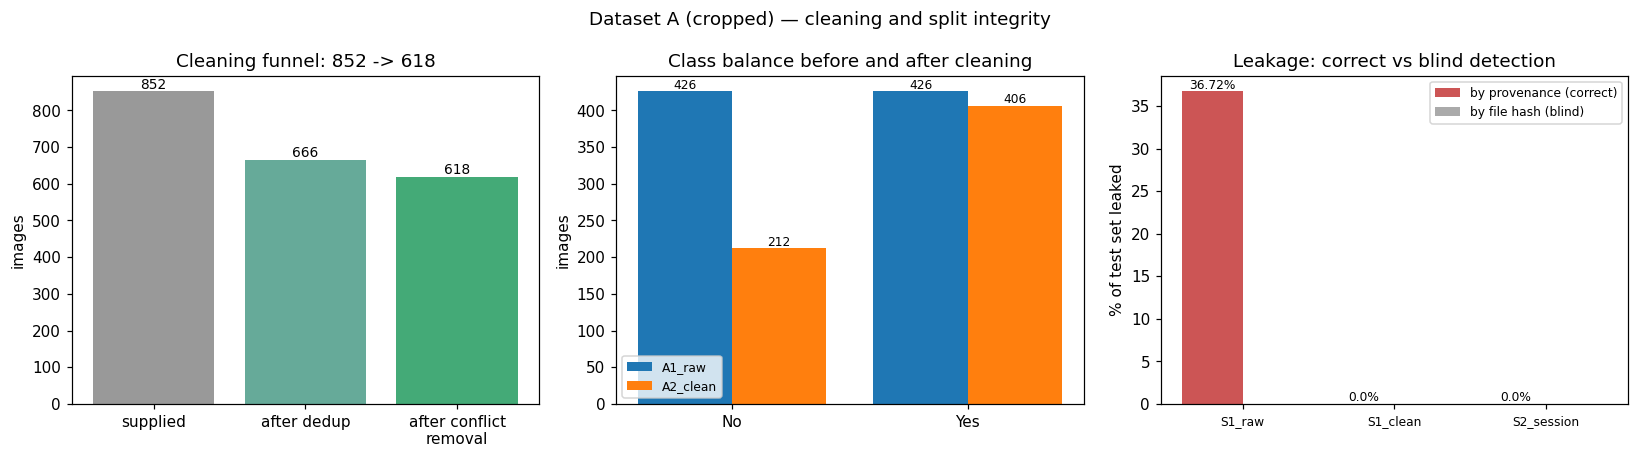

[saved] /content/drive/MyDrive/DyslexAI/results/figures/A_cleaning_and_leakage_cropped.png


In [ ]:
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 110

fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))

# --- Panel 1: cleaning funnel ----------------------------------------------
stages = ['supplied', 'after dedup', 'after conflict\nremoval']
counts = [len(meta),
          len(meta) - (removed['removal_reason'] == 'redundant_duplicate_copy').sum(),
          len(a2)]
bars = ax[0].bar(stages, counts, color=['#999', '#6a9', '#4a7'])
ax[0].set_ylabel('images')
ax[0].set_title(f'Cleaning funnel: {len(meta)} -> {len(a2)}')
for b, c in zip(bars, counts):
    ax[0].text(b.get_x() + b.get_width()/2, c, str(c), ha='center', va='bottom', fontsize=9)

# --- Panel 2: class balance -------------------------------------------------
labels = ['No', 'Yes']
before = [(meta['class_label'] == l).sum() for l in labels]
after  = [(a2['class_label']   == l).sum() for l in labels]
x = np.arange(len(labels))
ax[1].bar(x - 0.2, before, width=0.4, label='A1_raw')
ax[1].bar(x + 0.2, after,  width=0.4, label='A2_clean')
ax[1].set_xticks(x); ax[1].set_xticklabels(labels)
ax[1].set_ylabel('images'); ax[1].set_title('Class balance before and after cleaning')
ax[1].legend(fontsize=8)
for i, (b, a_) in enumerate(zip(before, after)):
    ax[1].text(i - 0.2, b, str(b), ha='center', va='bottom', fontsize=8)
    ax[1].text(i + 0.2, a_, str(a_), ha='center', va='bottom', fontsize=8)

# --- Panel 3: leakage, both methods ----------------------------------------
names = [n.split()[0] for n in leak['split_name']]
prov  = list(leak['test_leaked_pct'])
hashb = [h['hash-based leakage %'] for h in hash_based] + [0.0] * (len(names) - len(hash_based))
xx = np.arange(len(names))
ax[2].bar(xx - 0.2, prov,  width=0.4, label='by provenance (correct)', color='#c55')
ax[2].bar(xx + 0.2, hashb, width=0.4, label='by file hash (blind)',    color='#aaa')
ax[2].set_xticks(xx); ax[2].set_xticklabels(names, fontsize=8)
ax[2].set_ylabel('% of test set leaked')
ax[2].set_title('Leakage: correct vs blind detection')
ax[2].legend(fontsize=8)
for i, v in enumerate(prov):
    ax[2].text(i - 0.2, v, f'{v}%', ha='center', va='bottom', fontsize=8)

fig.suptitle('Dataset A (cropped) — cleaning and split integrity', fontsize=12)
fig.tight_layout()
fig.savefig(FIGURES_DIR / 'A_cleaning_and_leakage_cropped.png', bbox_inches='tight')
plt.show()
print(f'[saved] {FIGURES_DIR / "A_cleaning_and_leakage_cropped.png"}')

---
# STAGE 9 — Report

In [ ]:
session_lines = ''
if RUN_SESSION_DIAGNOSTIC:
    session_lines = (f"  S2_session   A2_clean, capture day {test_group} held out\n"
                     f"               DIAGNOSTIC ONLY - not a headline result")
else:
    session_lines = '  S2_session   skipped'

report = f"""
{'='*72}
DATASET A (CROPPED) - CLEANING AND SPLIT REPORT
{'='*72}
Generated : {datetime.now().isoformat(timespec='seconds')}
Seed      : {SEED}
Input     : manually ROI-cropped images (DYS-24/25/26)
Jira      : DYS-16

--- CLEANING POLICY APPLIED --------------------------------------------
  Rule 0  identify duplicates by PROVENANCE (inherited duplicate_group),
          never by hashing the cropped file
  Rule 1  collapse each duplicate group to one canonical copy
          (EXIF present > original-looking filename > alphabetical)
  Rule 2  remove ALL members of cross-class contradiction groups
  Rule 3  remove corrupted files
  Rule 4  log every removal with a reason

--- BEFORE / AFTER -----------------------------------------------------
  before                     : {len(meta)}
  after                      : {len(a2)}
  removed                    : {len(removed)}
      redundant copies       : {(removed['removal_reason']=='redundant_duplicate_copy').sum()}
      cross-class conflicts  : {(removed['removal_reason']=='cross_class_label_conflict').sum()}
      corrupted              : {(removed['removal_reason']=='corrupted_file').sum()}

  duplicate groups           : {n_dup_groups}
  cross-class contradictions : {n_conflict_groups}

--- CLASS DISTRIBUTION -------------------------------------------------
  A1_raw    No={(meta['class_label']=='No').sum():>4}  Yes={(meta['class_label']=='Yes').sum():>4}
  A2_clean  No={(a2['class_label']=='No').sum():>4}  Yes={(a2['class_label']=='Yes').sum():>4}
  A2 imbalance Yes:No = {(a2['class_label']=='Yes').sum() / (a2['class_label']=='No').sum():.2f} : 1

--- SPLITS -------------------------------------------------------------
  S1_raw       A1_raw,   stratified random 70/15/15
  S1_clean     A2_clean, stratified random 70/15/15  [PRIMARY]
{session_lines}

--- LEAKAGE AUDIT (by provenance, not by file hash) --------------------
{leak[['split_name','n_train','n_val','n_test','test_leaked','test_leaked_pct']].to_string(index=False)}

--- LIMITATIONS --------------------------------------------------------
  * Participant IDs are unavailable. NO split here is writer-independent
    and none may be described as such.
  * The primary split is a random image-level split. Its only protection
    is that A2_clean holds one file per source image.
  * Date/session grouping is retained as a DIAGNOSTIC only. A capture day
    is not a participant; one session contains many children.
  * The leakage audit detects shared SOURCE images. Two different
    characters written by the same child are undetectable without
    participant IDs.
  * Hashing cropped files CANNOT detect duplication. Any future pipeline
    step must use duplicate_group.
  * Yes/No are supplied dataset labels. They do not establish clinical
    validity and are not treated as diagnoses.
{'='*72}
""".strip()

print(report)
(REPORTS_DIR / 'dataset_a_cleaning_report.txt').write_text(report)
print(f'\n[saved] {REPORTS_DIR / "dataset_a_cleaning_report.txt"}')

DATASET A (CROPPED) - CLEANING AND SPLIT REPORT
Generated : 2026-09-26T12:25:20
Seed      : 42
Input     : manually ROI-cropped images (DYS-24/25/26)
Jira      : DYS-16

--- CLEANING POLICY APPLIED --------------------------------------------
  Rule 0  identify duplicates by PROVENANCE (inherited duplicate_group),
          never by hashing the cropped file
  Rule 1  collapse each duplicate group to one canonical copy
          (EXIF present > original-looking filename > alphabetical)
  Rule 2  remove ALL members of cross-class contradiction groups
  Rule 3  remove corrupted files
  Rule 4  log every removal with a reason

--- BEFORE / AFTER -----------------------------------------------------
  before                     : 852
  after                      : 618
  removed                    : 234
      redundant copies       : 186
      cross-class conflicts  : 48
      corrupted              : 0

  duplicate groups           : 147
  cross-class contradictions : 20

--- CLASS DISTRIBU

---
# Experiment Log

## What we actually did

1. Rebuilt the cropped images and loaded the provenance-carrying metadata from Notebook 01b,
   with a guard that stops the notebook if provenance is missing.
2. Rewrote the cleaning policy around **provenance-based** duplicate identification, because
   hashing cropped files cannot detect duplication.
3. Selected one canonical file per duplicate group using a deterministic documented ranking.
4. Removed all members of the 20 cross-class contradiction groups.
5. Verified with seven assertions, including one that fails if deduplication silently did
   nothing — the specific failure this revision exists to prevent.
6. Built the splits with a stratified random split as the primary evaluation.
7. Rewrote the leakage audit to count shared **source images** rather than identical files, and
   demonstrated that the previous hash-based audit reports 0% on a split that genuinely leaks.

## What we learned

**A correct-looking check can be a broken check.** The hash-based leakage audit would have
passed every split on this data, including the one with substantial leakage. Nothing would have
errored. The figure would simply have been wrong.

**Provenance is more durable than content.** Pixels changed; recorded structure did not. The
audit survived a destructive preprocessing step only because filenames were preserved and the
original findings were written down.

## What we can tell

> After the images were manually cropped, we found that our duplicate-detection method no longer
> worked — hand-drawn crops of identical source images are not byte-identical. We rebuilt
> deduplication to use provenance recovered from the original audit, and rewrote the leakage
> audit to count shared source images rather than identical files. We also show what the
> previous method would have reported on this data, which is zero leakage on a split that leaks.

## Limitations carried forward

| Limitation | Effect on our claims |
|---|---|
| No participant IDs | No writer-independent claim is possible |
| Primary split is random at image level | The weakest defensible evaluation; stated as such |
| Session grouping demoted to diagnostic | We no longer report a session-generalisation result as a headline |
| Leakage audit sees shared source images only | Same-writer leakage remains unmeasurable |
| Class imbalance after cleaning | Accuracy alone is misleading; per-class metrics required |

## Requirements this generates for our own dataset

| Problem here | Requirement for our collection |
|---|---|
| Preprocessing destroyed duplicate detection | Hash at ingest, before any processing, and store it permanently |
| Structure survived only via filenames | Every step must preserve a stable ID back to the original capture |
| A check silently stopped working | Pipeline checks must assert expected counts, not just report findings |
| No participant grouping possible | `participant_id` recorded at capture, splits grouped by it, always |

---
